In [1]:
import torch
import ultralytics

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    
print(f"Ultralytics Version: {ultralytics.__version__}")

CUDA Available: True
Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
Ultralytics Version: 8.4.8


**Import Data and Train Model**

In [2]:
import kagglehub
from ultralytics import YOLO
import os
import yaml

c:\Users\nicho\anaconda3\envs\542_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# download dataset
ds_path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")
print(f"Dataset downloaded to: {ds_path}")

# patch YAML for local use
orig_yaml = os.path.join(ds_path, "data.yaml")
with open(orig_yaml, "r") as f:
    data = yaml.safe_load(f)

# update the root path to the local kagglehub directory
data["path"] = ds_path

local_yaml = "local_smoke_fire.yaml"
with open(local_yaml, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

# train locally
model = YOLO("yolo11n.pt") 
model.train(
    data=local_yaml, 
    epochs=50, 
    imgsz=640, 
    batch=16,     
    device=0, 
    workers=4,    
    amp=True      
)
# export to tensorflow
model.export(format="onnx")

Dataset downloaded to: C:\Users\nicho\.cache\kagglehub\datasets\sayedgamal99\smoke-fire-detection-yolo\versions\1
New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.8  Python-3.11.14 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=local_smoke_fire.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ra

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

requirements: Ultralytics requirements ['tf_keras<=2.19.0', 'sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 23.6 MB/s  0:00:00
   ---------------------------------------- 0.0/6.1 MB ? eta -:--:--
   -------------------- ------------------- 3.1/6.1 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------  6.0/6.1 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------- 6.1/6.1 MB 14.3 MB/s  0:00:00

   ------ --------------------------------- 1/6 [onnx2tf]
   ------ --------------------------------- 1/6 [onnx2tf]
   ------ --------------------------------- 1/6 [onnx2tf]
   ------ --------------------------------- 1/6 [onnx2tf]
   ------ --------------------------------- 1/6 [onnx2tf]


ModuleNotFoundError: No module named 'onnx.serialization'

**Resume Model if Training Interrupted**

In [5]:
model = YOLO("runs/detect/train7/weights/best.pt") 
model.export(format="onnx")

Ultralytics 8.4.8  Python-3.11.14 torch-2.6.0+cu124 CPU (13th Gen Intel Core(TM) i7-13620H)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs\detect\train7\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.2 MB)

ONNX: starting export with onnx 1.14.1 opset 19...
ONNX: slimming with onnxslim 0.1.82...
ONNX: export success  2.2s, saved as 'runs\detect\train7\weights\best.onnx' (10.1 MB)

Export complete (2.8s)
Results saved to C:\Users\nicho\Desktop\CPE542\runs\detect\train7\weights
Predict:         yolo predict task=detect model=runs\detect\train7\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\train7\weights\best.onnx imgsz=640 data=local_smoke_fire.yaml  
Visualize:       https://netron.app


'runs\\detect\\train7\\weights\\best.onnx'

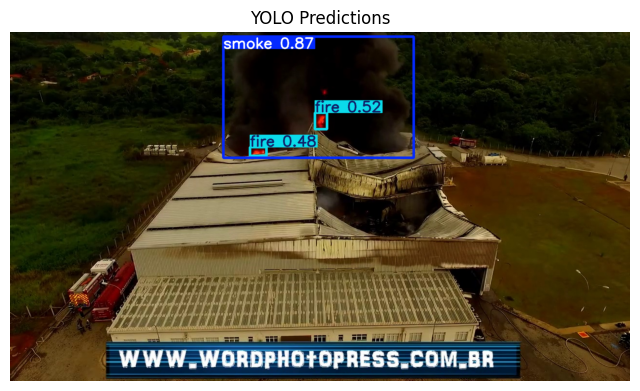

In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

def predict_and_show(model_path, image_path, conf=0.25, imgsz=640):
    """
    run YOLO inference on an image and display bounding boxes
    """
    # load model
    model = YOLO(model_path)

    # run prediction
    results = model.predict(
        source=image_path,
        conf=conf,
        imgsz=imgsz,
        save=False,
        verbose=False
    )

    # ultralytics gives us an annotated image already
    annotated_img = results[0].plot()

    # convert BGR to RGB for matplotlib
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # show image
    plt.figure(figsize=(8, 8))
    plt.imshow(annotated_img)
    plt.axis("off")
    plt.title("YOLO Predictions")
    plt.show()


predict_and_show(
    model_path="runs/detect/train7/weights/best.pt",
    image_path="data/train/images/WEB09307.jpg",
    conf=0.2
)
